In [33]:
import math
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import numpy as np

## Seismic Story Drift 

All seismic story drifts were obtained directly from MIDAS and expressed in terms of 1/x, where x is the reciprocal of the story drift ratio. The tolerable drift was calculated and reduced by the amplification for inelastic drift which is 0.7R.

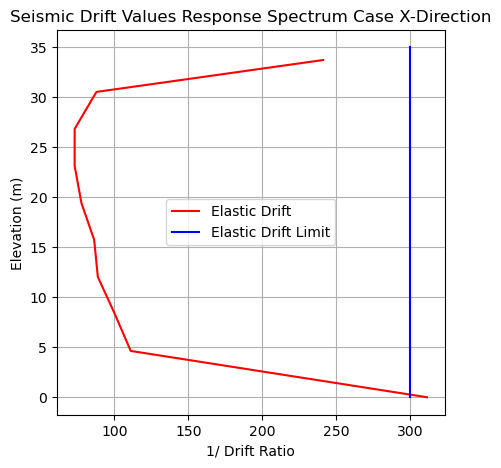

In [46]:
def driftSolve(dtop,dbot,ht):
    value = (dtop-dbot)/ht
    return value

displacement_f = pd.read_excel('displacement.xls')
# print(displacement_f)

length = len(displacement_f)

height = []
displacement = []

dtop = []
dbot = []

i = 0
while i < length:
#     print(i)
#     case_index = displacement_f['Load Case'][i]
#     level_index = displacement_f['level'][i]
    story_index = displacement_f['story'][i]

    disp = displacement_f['max'][i]
    dtop.append(disp)
    n_slice = length - 2
    if i < n_slice:
        disp_lower = displacement_f['max'][i+1]
        dbot.append(disp_lower)
    else:
        dbot.append(0)  
        
    drift_ht.append(story_index)
    i = i + 1

x_graph = []
y_graph = []
drift_data = []
i = 0
length2 = len(dtop)
while i < length2:
    level_index = displacement_f['level'][i]
#     print(level_index)
    if i != 0:
        inelastic_drift = driftSolve(dtop[i],dbot[i],drift_ht[i])
        elastic_drift = driftSolve(dtop[i],dbot[i],drift_ht[i])*8.5*0.7
        drift_data.append(inelastic_drift)
        x_graph.append((1/elastic_drift))
        y_graph.append(level_index)
        
    i = i + 1
edlx = [300,300]
edly = [0,35]
# print(drift_ht) 
plt.figure(figsize=(5, 5))
plt.plot(x_graph, y_graph, label = "Elastic Drift", color="red")
plt.plot(edlx, edly, label = "Elastic Drift Limit", color="blue")
plt.legend()
plt.grid()
plt.title("Seismic Drift Values Response Spectrum Case X-Direction")
plt.xlabel("1/ Drift Ratio")
plt.ylabel("Elevation (m)")
plt.show()

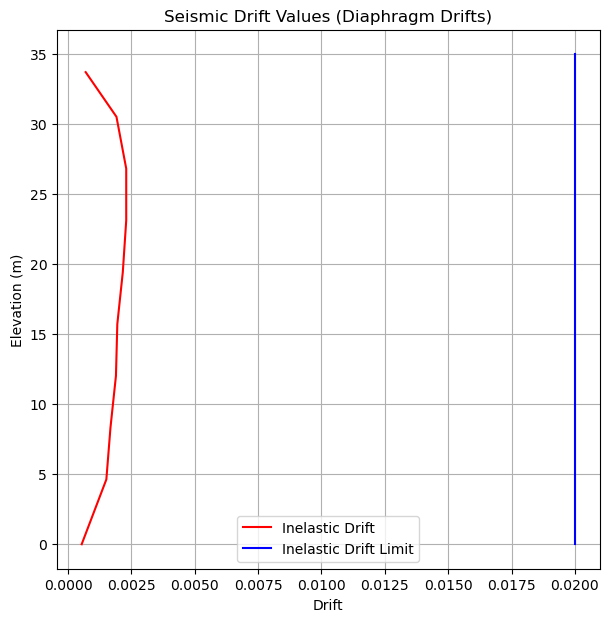

In [48]:
edlx = [0.02,0.02]
edly = [0,35]

plt.figure(figsize=(7, 7))
plt.plot(drift_data, y_graph, label = "Inelastic Drift", color="red")
plt.plot(edlx, edly, label = "Inelastic Drift Limit", color="blue")
plt.legend()
plt.grid()
plt.title("Seismic Drift Values (Diaphragm Drifts)")
plt.xlabel("Drift")
plt.ylabel("Elevation (m)")
plt.show()

## Story Shear
(Response Spectrum Case)

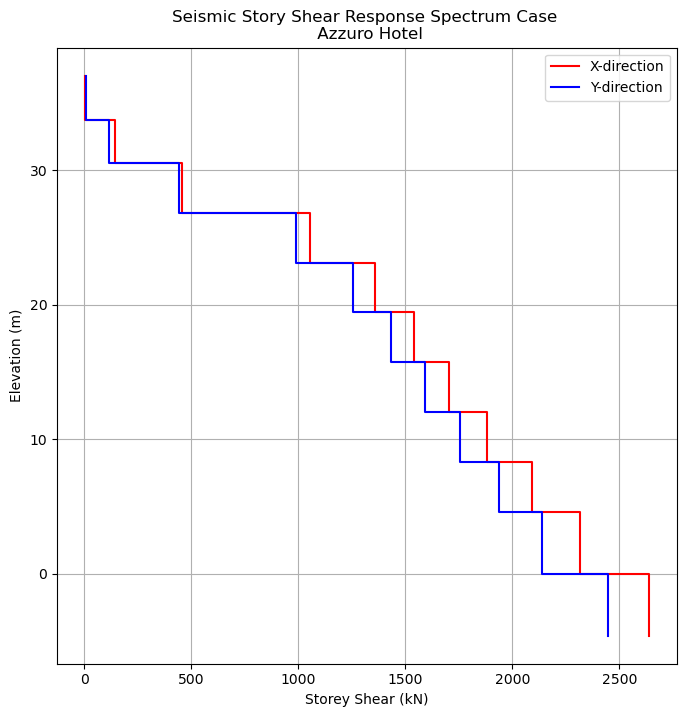

In [35]:
ssrsf = pd.read_excel('rsshear.xls')

length = len(ssrsf)

height = []
shear_major = []
shear_ortho = []


i = 0
while i < length:
    case_index = ssrsf['case'][i]
    if(case_index == 'RS-Major(RS)'):
        height.append(ssrsf['height'][i])    
    i = i + 1
i = 0
while i < length:
    case_index = ssrsf['case'][i]
    if(case_index == 'RS-Major(RS)'):
        shear_x = ssrsf['X'][i]
        shear_y = ssrsf['Y'][i]
        resultant = math.sqrt(math.pow(shear_x,2) + math.pow(shear_y,2))
        shear_major.append(resultant)
    if(case_index == 'RS-Ortho(RS)'):
        shear_x = ssrsf['X'][i]
        shear_y = ssrsf['Y'][i]
        resultant = math.sqrt(math.pow(shear_x,2) + math.pow(shear_y,2))
        shear_ortho.append(resultant)     
    i = i + 1
    

plt.figure(figsize=(8, 8))
plt.step(shear_major, height, label = "X-direction", color="red")
plt.step(shear_ortho, height, label = "Y-direction", color="blue")
plt.legend()
plt.grid()
plt.title("Seismic Story Shear Response Spectrum Case \n Azzuro Hotel")
plt.xlabel("Storey Shear (kN)")
plt.ylabel("Elevation (m)")
plt.show()


## Overturning Moment

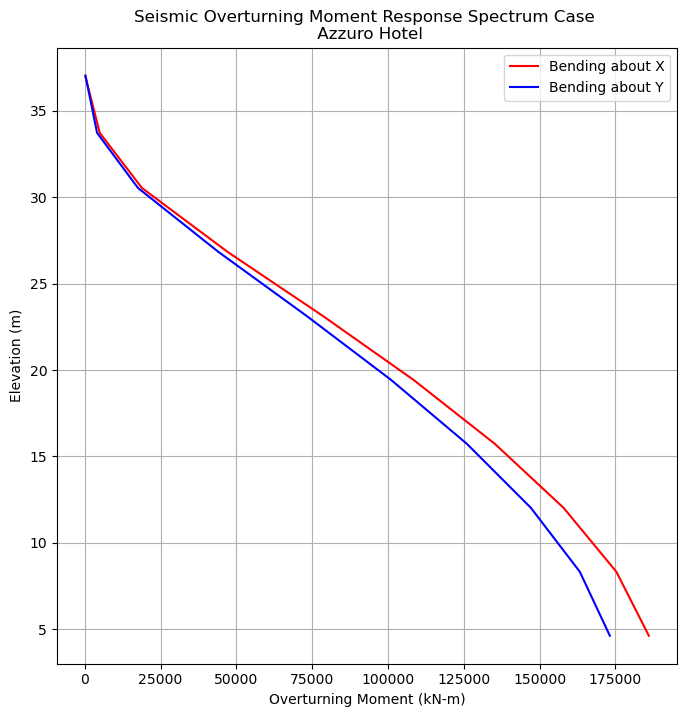

In [36]:
length = len(shear_major)
OT_major = []
OT_ortho = []
OT_height = []
ot_at_x = 0
ot_at_y = 0
i = 0

while i < length:
    height_index = height[i]
    if height_index > 0:
        major = shear_major[i]*height[i]
        ortho = shear_ortho[i]*height[i]
        ot_at_x = ot_at_x + major
        ot_at_y = ot_at_y + ortho
        OT_major.append(ot_at_x)
        OT_ortho.append(ot_at_y)
        OT_height.append(height[i])
    i = i + 1
    
plt.figure(figsize=(8, 8))
plt.plot(OT_major, OT_height, label = "Bending about X", color="red")
plt.plot(OT_ortho, OT_height, label = "Bending about Y", color="blue")
plt.grid()
plt.legend()
plt.title("Seismic Overturning Moment Response Spectrum Case \n Azzuro Hotel")
plt.xlabel("Overturning Moment (kN-m)")
plt.ylabel("Elevation (m)")

plt.show()

In [ ]:
##Soft Story

